# NiN

## 简介
出自新加坡国立大学 2014 年的论文 "Network In Network"，完全不采用全连接层，从而减少参数量，且取得了超过AlexNet的性能。AlexNet网络参数大小是230M，NIN只需要29M。

![NiN](./images/NiN.png)

## 全连接层的问题
- 卷积层参数量: $c_i \times c_o \times k^2$
- 全连接层参数量: $c_i \times c_o \times h \times w$

  - LeNet-5: $16 \times 120 \times 5 \times 5 = 48K$
  - AlexNet: $256 \times 4096 \times 6 \times 6 = 37M$
  - VGG: $512 \times 4096 \times 7 \times 7 = 102M$

图像尺寸往往很大，所以全连接层参数量远大于卷积层参数量，效率、过拟合都是问题。

## NiN 块
一个卷积层后面接两个“全连接卷积层”
- 1x1 卷积核
- 步幅 1，无填充
- 输出形状与卷积层输出形状相同

相当于每个像素位置经过 $(c_i, c_o)$ 的 MLP 进行非线性变换。

## GAP 全局平均池化层
高宽与输入一致的无步幅、无填充的平均池化层，把每个通道的特征图压缩为一个数。
- 输出形状: $(c_o, 1, 1)$
- 可降低后续 MLP 参数量
- 不后接 MLP 则强制每个通道的特征图与类别一一绑定


## NiN 架构
- 无全连接层
- 交替使用 NiN 块和 MaxPooling 层（减小高宽，增大通道数）
- 最后使用全局平均池化层得到输出

![VGG and NiN](./images/VGG_and_NiN.svg)


## 实现


In [1]:
import torch
from torch import nn
import torchinfo
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### NiN 块
一个卷积层和两个 1x1 卷积层，`kernel_size`, `strides`, `padding` 都是第一个卷积层的参数


In [2]:
def nin_block(in_channels: int, out_channels: int,
              kernel_size: int, strides: int, padding: int)-> nn.Sequential:
    return nn.Sequential(
        # 卷积层
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding), nn.ReLU(),
        # 两个 1x1 卷积层
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU()
    )


### NiN 网络
- 4 个 NiN 块
- 3 个 MaxPooling 层
- 全局平均池化层

卷积层参数都和 AlexNet 相同


In [3]:
net = nn.Sequential(
    # 忽略 batch_size，(3, 224, 224)
    # NiN 块 1
    nin_block(1, 96, kernel_size=11, strides=4, padding=0), # (96, 54, 54)
    nn.MaxPool2d(kernel_size=3, stride=2), # (96, 26, 26)
    # NiN 块 2
    nin_block(96, 256, kernel_size=5, strides=1, padding=2), # (256, 26, 26)
    nn.MaxPool2d(kernel_size=3, stride=2), # (256, 12, 12)
    # NiN 块 3
    nin_block(256, 384, kernel_size=3, strides=1, padding=1), # (384, 12, 12)
    nn.MaxPool2d(kernel_size=3, stride=2), # (384, 5, 5)
    nn.Dropout(0.5), # 《anyway》
    # NiN 块 4
    nin_block(384, 10, kernel_size=3, strides=1, padding=1), # (10, 5, 5)
    # 全局平均池化层，AdaptiveAvgPool2d 指定输出大小为 (1, 1)，自动计算步幅和填充
    nn.AdaptiveAvgPool2d((1, 1)), # (10, 1, 1)
    # 展平输出
    nn.Flatten() # (10)
)

In [4]:
torchinfo.summary(net,
                  input_size=(1, 1, 224, 224),
                  col_width=20,
                  col_names=["input_size", "output_size", "num_params", "kernel_size"])

Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Kernel Shape
Sequential                               [1, 1, 224, 224]     [1, 10]              --                   --
├─Sequential: 1-1                        [1, 1, 224, 224]     [1, 96, 54, 54]      --                   --
│    └─Conv2d: 2-1                       [1, 1, 224, 224]     [1, 96, 54, 54]      11,712               [11, 11]
│    └─ReLU: 2-2                         [1, 96, 54, 54]      [1, 96, 54, 54]      --                   --
│    └─Conv2d: 2-3                       [1, 96, 54, 54]      [1, 96, 54, 54]      9,312                [1, 1]
│    └─ReLU: 2-4                         [1, 96, 54, 54]      [1, 96, 54, 54]      --                   --
│    └─Conv2d: 2-5                       [1, 96, 54, 54]      [1, 96, 54, 54]      9,312                [1, 1]
│    └─ReLU: 2-6                         [1, 96, 54, 54]      [1, 96, 54, 54]      --                   --
├─MaxPool2d: 

依旧 Fashion-MNIST


loss 0.376, train acc 0.859, test acc 0.851
7365.1 examples/sec on cuda:0


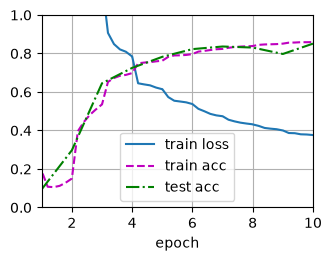

In [5]:
num_epochs = 10
lr = 0.1
batch_size = 128
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size=batch_size, resize=224)

util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, util.try_gpu(), ylim=(0, 1))

In [6]:
torch.save(net.state_dict(), "./models/NiN.pth")